In [1]:
import seaborn as sn
print(sn.__version__)

0.13.2


(36, 4)
        Disease  Age  Gender Smoker status
0      diseased   43    Male        Smoker
1  not diseased   18    Male        Smoker
2      diseased   22  Female    Non-smoker
3      diseased   25    Male    Non-smoker
4  not diseased   45  Female        Smoker
Disease          0
Age              0
Gender           0
Smoker status    0
dtype: int64
(28, 3)
(28,)
(8, 3)
(8,)
Confusion Matrix:
[[2 0]
 [2 4]]
Accuracy Score: 0.75
Accuracy in Percentage: 75 %


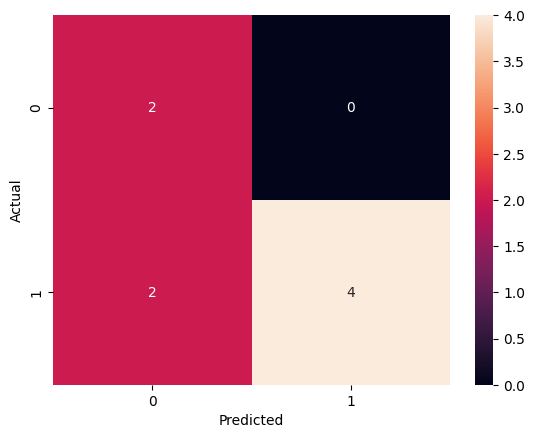

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

data = pd.read_csv("medical_example.csv")

print(data.shape)
print(data.head())
print(data.isnull().sum())

data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})
data["Smoker status"] = data["Smoker status"].map({"Smoker": 1, "Non-smoker": 0})
data["Disease"] = data["Disease"].map({"diseased": 1, "not diseased": 0})

X = data[["Age", "Gender", "Smoker status"]]
y = data["Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

model = LogisticRegression(solver="lbfgs", max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_mat)

accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)
print("Accuracy in Percentage:", int(accuracy * 100), "%")

conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)

sn.heatmap(conf_mat, annot=True, fmt="d")
plt.show()